# 第11章: 正規分布に関する検定

## 学習目標
- z検定とt検定を理解し適用できる
- 分散に関するカイ二乗検定を理解する
- 等分散性のF検定を理解する
- 二標本検定を実行できる

## 📋 学習メタ情報

### 推定学習時間
**90〜120分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

t検定、F検定、カイ二乗検定は、正規分布を前提とした最も基本的な検定手法です。2群比較や分散の検定など、実務で頻繁に使われます。

### 実世界での応用

**A/Bテストの平均比較**: t検定で2群の平均値の差を検定

**分散の均一性検定**: F検定で2群の分散が等しいか検定（t検定の前提確認）

**適合度検定**: カイ二乗検定でデータが理論分布に従うか検定

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 11.1 z検定（分散既知）

### 検定統計量
$$Z = \frac{\bar{X} - \mu_0}{\sigma/\sqrt{n}} \sim N(0, 1)$$

### 棄却域
- 両側検定: $|Z| > z_{\alpha/2}$
- 右片側検定: $Z > z_\alpha$
- 左片側検定: $Z < -z_\alpha$

z検定 (σ既知)
H0: μ = 100

サンプルサイズ: n = 36
標本平均: X̄ = 103.57
既知のσ: 15

z統計量 = 1.428
p値 (両側): 0.1532
p値 (右片側): 0.0766


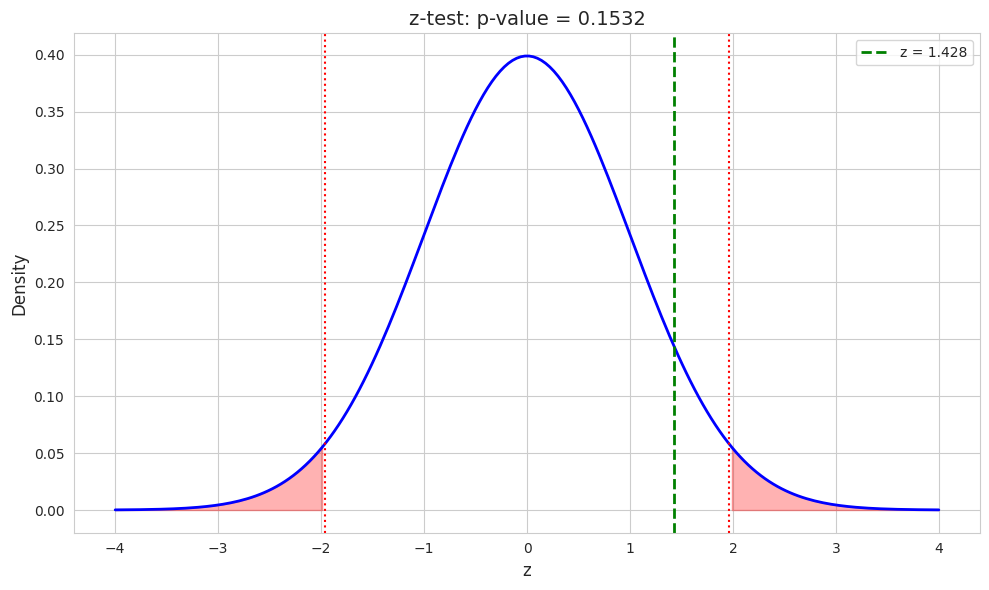

In [2]:
# z検定の例
np.random.seed(123)

# Population parameters
mu_0 = 100  # Hypothesized mean
sigma = 15  # Known standard deviation
n = 36
alpha = 0.05

# Generate sample (actually from mu = 105)
true_mu = 105
sample = np.random.normal(true_mu, sigma, n)
x_bar = np.mean(sample)

# z-test
z_stat = (x_bar - mu_0) / (sigma / np.sqrt(n))
p_value_two = 2 * (1 - stats.norm.cdf(abs(z_stat)))
p_value_right = 1 - stats.norm.cdf(z_stat)

print("z検定 (σ既知)")
print("="*50)
print(f"H0: μ = {mu_0}")
print(f"\nサンプルサイズ: n = {n}")
print(f"標本平均: X̄ = {x_bar:.2f}")
print(f"既知のσ: {sigma}")
print(f"\nz統計量 = {z_stat:.3f}")
print(f"p値 (両側): {p_value_two:.4f}")
print(f"p値 (右片側): {p_value_right:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(-4, 4, 200)
ax.plot(x, stats.norm.pdf(x), 'b-', linewidth=2)

z_crit = stats.norm.ppf(1 - alpha/2)
ax.fill_between(x[x > z_crit], stats.norm.pdf(x[x > z_crit]), alpha=0.3, color='red')
ax.fill_between(x[x < -z_crit], stats.norm.pdf(x[x < -z_crit]), alpha=0.3, color='red')

ax.axvline(z_stat, color='green', linestyle='--', linewidth=2, label=f'z = {z_stat:.3f}')
ax.axvline(z_crit, color='red', linestyle=':', linewidth=1.5)
ax.axvline(-z_crit, color='red', linestyle=':', linewidth=1.5)

ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'z-test: p-value = {p_value_two:.4f}', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 11.2 t検定（一標本、分散未知）

### 検定統計量
$$T = \frac{\bar{X} - \mu_0}{S/\sqrt{n}} \sim t(n-1)$$

### 棄却域
- 両側検定: $|T| > t_{\alpha/2}(n-1)$
- 右片側検定: $T > t_\alpha(n-1)$

t検定 (一標本、σ未知)
H0: μ = 50

サンプルサイズ: n = 20
標本平均: X̄ = 54.25
標本標準偏差: S = 8.62
自由度: 19

t統計量 = 2.204
p値 = 0.0401

SciPy結果: t = 2.204, p = 0.0401


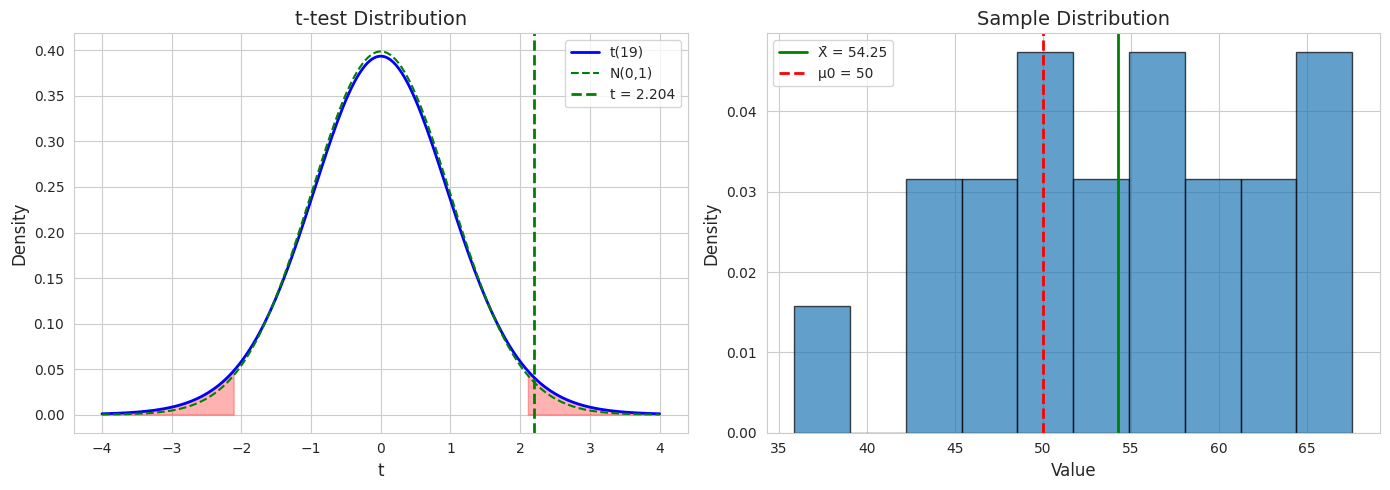

In [3]:
# t検定の例
np.random.seed(456)

mu_0 = 50
n = 20
alpha = 0.05

# Generate sample
sample = np.random.normal(52, 8, n)
x_bar = np.mean(sample)
s = np.std(sample, ddof=1)

# t-test
t_stat = (x_bar - mu_0) / (s / np.sqrt(n))
df = n - 1
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print("t検定 (一標本、σ未知)")
print("="*50)
print(f"H0: μ = {mu_0}")
print(f"\nサンプルサイズ: n = {n}")
print(f"標本平均: X̄ = {x_bar:.2f}")
print(f"標本標準偏差: S = {s:.2f}")
print(f"自由度: {df}")
print(f"\nt統計量 = {t_stat:.3f}")
print(f"p値 = {p_value:.4f}")

# Compare with scipy
t_scipy, p_scipy = stats.ttest_1samp(sample, mu_0)
print(f"\nSciPy結果: t = {t_scipy:.3f}, p = {p_scipy:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# t-distribution
x = np.linspace(-4, 4, 200)
axes[0].plot(x, stats.t.pdf(x, df), 'b-', linewidth=2, label=f't({df})')
axes[0].plot(x, stats.norm.pdf(x), 'g--', linewidth=1.5, label='N(0,1)')

t_crit = stats.t.ppf(1 - alpha/2, df)
axes[0].fill_between(x[x > t_crit], stats.t.pdf(x[x > t_crit], df), alpha=0.3, color='red')
axes[0].fill_between(x[x < -t_crit], stats.t.pdf(x[x < -t_crit], df), alpha=0.3, color='red')
axes[0].axvline(t_stat, color='green', linestyle='--', linewidth=2, label=f't = {t_stat:.3f}')

axes[0].set_xlabel('t', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('t-test Distribution', fontsize=14)
axes[0].legend()

# Sample data
axes[1].hist(sample, bins=10, density=True, alpha=0.7, edgecolor='black')
axes[1].axvline(x_bar, color='green', linewidth=2, label=f'X̄ = {x_bar:.2f}')
axes[1].axvline(mu_0, color='red', linestyle='--', linewidth=2, label=f'μ0 = {mu_0}')
axes[1].set_xlabel('Value', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Sample Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 11.3 分散のカイ二乗検定

### 検定統計量
$$\chi^2 = \frac{(n-1)S^2}{\sigma_0^2} \sim \chi^2(n-1)$$

### 棄却域
- 両側検定: $\chi^2 < \chi^2_{1-\alpha/2}(n-1)$ または $\chi^2 > \chi^2_{\alpha/2}(n-1)$
- $H_1: \sigma^2 > \sigma_0^2$: $\chi^2 > \chi^2_\alpha(n-1)$

分散のカイ二乗検定
H0: σ² = 25

サンプルサイズ: n = 20
標本分散: S² = 34.82
自由度: 19

χ²統計量 = 26.465
棄却域: χ² < 8.907 or χ² > 32.852
p値 = 0.2355


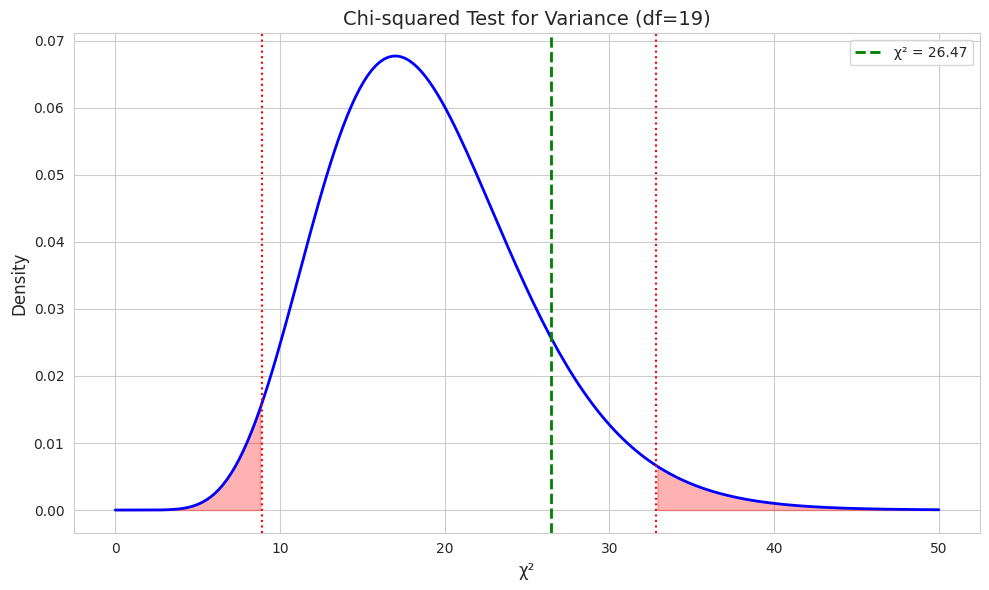

In [4]:
# 分散のカイ二乗検定
np.random.seed(789)

sigma2_0 = 25  # Hypothesized variance
n = 20
alpha = 0.05

# Generate sample (true variance = 36)
sample = np.random.normal(0, 6, n)  # True σ = 6, σ² = 36
s2 = np.var(sample, ddof=1)

# Chi-squared test
df = n - 1
chi2_stat = (n - 1) * s2 / sigma2_0

# Two-sided p-value
p_value = 2 * min(stats.chi2.cdf(chi2_stat, df), 1 - stats.chi2.cdf(chi2_stat, df))

# Critical values
chi2_lower = stats.chi2.ppf(alpha/2, df)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df)

print("分散のカイ二乗検定")
print("="*50)
print(f"H0: σ² = {sigma2_0}")
print(f"\nサンプルサイズ: n = {n}")
print(f"標本分散: S² = {s2:.2f}")
print(f"自由度: {df}")
print(f"\nχ²統計量 = {chi2_stat:.3f}")
print(f"棄却域: χ² < {chi2_lower:.3f} or χ² > {chi2_upper:.3f}")
print(f"p値 = {p_value:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 50, 200)
ax.plot(x, stats.chi2.pdf(x, df), 'b-', linewidth=2)

ax.fill_between(x[x < chi2_lower], stats.chi2.pdf(x[x < chi2_lower], df), alpha=0.3, color='red')
ax.fill_between(x[x > chi2_upper], stats.chi2.pdf(x[x > chi2_upper], df), alpha=0.3, color='red')

ax.axvline(chi2_stat, color='green', linestyle='--', linewidth=2, label=f'χ² = {chi2_stat:.2f}')
ax.axvline(chi2_lower, color='red', linestyle=':', linewidth=1.5)
ax.axvline(chi2_upper, color='red', linestyle=':', linewidth=1.5)

ax.set_xlabel('χ²', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Chi-squared Test for Variance (df={df})', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 11.4 等分散性のF検定

### 検定統計量
$$F = \frac{S_1^2}{S_2^2} \sim F(n_1-1, n_2-1)$$

ここで $S_1^2 > S_2^2$ となるように並べる（片側検定の場合）。

### 仮説
- $H_0: \sigma_1^2 = \sigma_2^2$
- $H_1: \sigma_1^2 \neq \sigma_2^2$ (両側) または $\sigma_1^2 > \sigma_2^2$ (片側)

等分散性のF検定
H0: σ1² = σ2²

サンプル1: n1 = 25, S1² = 36.96
サンプル2: n2 = 30, S2² = 35.84

F統計量 = 1.031
自由度: (24, 29)
p値 = 0.9278

Levene検定: F = 0.050, p = 0.8231


/tmp/ipykernel_14166/2366483888.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([sample1, sample2], labels=['Sample 1', 'Sample 2'])


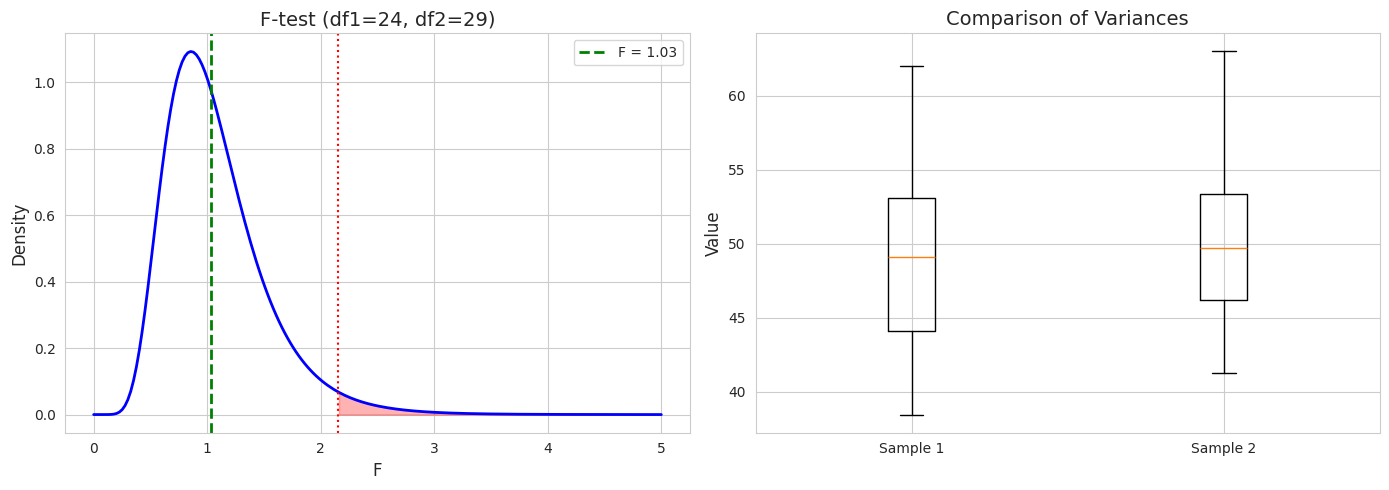

In [5]:
# F検定の例
np.random.seed(111)

# Two samples
n1, n2 = 25, 30
sample1 = np.random.normal(50, 8, n1)  # σ1 = 8
sample2 = np.random.normal(50, 5, n2)  # σ2 = 5

s1_2 = np.var(sample1, ddof=1)
s2_2 = np.var(sample2, ddof=1)

# Ensure s1_2 > s2_2 for one-sided test
if s1_2 < s2_2:
    s1_2, s2_2 = s2_2, s1_2
    n1, n2 = n2, n1

# F-test
df1, df2 = n1 - 1, n2 - 1
f_stat = s1_2 / s2_2

# Two-sided p-value
p_value = 2 * (1 - stats.f.cdf(f_stat, df1, df2))

# Critical value
alpha = 0.05
f_crit = stats.f.ppf(1 - alpha/2, df1, df2)

print("等分散性のF検定")
print("="*50)
print(f"H0: σ1² = σ2²")
print(f"\nサンプル1: n1 = {n1}, S1² = {s1_2:.2f}")
print(f"サンプル2: n2 = {n2}, S2² = {s2_2:.2f}")
print(f"\nF統計量 = {f_stat:.3f}")
print(f"自由度: ({df1}, {df2})")
print(f"p値 = {p_value:.4f}")

# Compare with scipy
f_scipy, p_scipy = stats.levene(sample1, sample2)
print(f"\nLevene検定: F = {f_scipy:.3f}, p = {p_scipy:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F-distribution
x = np.linspace(0, 5, 200)
axes[0].plot(x, stats.f.pdf(x, df1, df2), 'b-', linewidth=2)
axes[0].fill_between(x[x > f_crit], stats.f.pdf(x[x > f_crit], df1, df2), alpha=0.3, color='red')
axes[0].axvline(f_stat, color='green', linestyle='--', linewidth=2, label=f'F = {f_stat:.2f}')
axes[0].axvline(f_crit, color='red', linestyle=':', linewidth=1.5)

axes[0].set_xlabel('F', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'F-test (df1={df1}, df2={df2})', fontsize=14)
axes[0].legend()

# Box plots
axes[1].boxplot([sample1, sample2], labels=['Sample 1', 'Sample 2'])
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Comparison of Variances', fontsize=14)

plt.tight_layout()
plt.show()

## 11.5 二標本t検定

### 等分散を仮定する場合
$$T = \frac{\bar{X} - \bar{Y}}{S_p\sqrt{1/n_1 + 1/n_2}} \sim t(n_1+n_2-2)$$

プールした分散: $S_p^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1+n_2-2}$

### 等分散を仮定しない場合（Welch's t-test）
$$T = \frac{\bar{X} - \bar{Y}}{\sqrt{S_1^2/n_1 + S_2^2/n_2}}$$

In [6]:
# 二標本t検定（等分散）
np.random.seed(222)

# Two samples
n1, n2 = 20, 25
sample1 = np.random.normal(105, 10, n1)
sample2 = np.random.normal(100, 10, n2)

mean1, mean2 = np.mean(sample1), np.mean(sample2)
var1, var2 = np.var(sample1, ddof=1), np.var(sample2, ddof=1)

# Pooled variance
sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
sp = np.sqrt(sp2)

# t-statistic
t_stat = (mean1 - mean2) / (sp * np.sqrt(1/n1 + 1/n2))
df = n1 + n2 - 2
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print("二標本t検定 (等分散)")
print("="*50)
print(f"H0: μ1 = μ2")
print(f"\nサンプル1: n1 = {n1}, X̄1 = {mean1:.2f}, S1² = {var1:.2f}")
print(f"サンプル2: n2 = {n2}, X̄2 = {mean2:.2f}, S2² = {var2:.2f}")
print(f"プールした標準偏差: Sp = {sp:.2f}")
print(f"\nt統計量 = {t_stat:.3f}")
print(f"自由度: {df}")
print(f"p値 = {p_value:.4f}")

# Compare with scipy
t_scipy, p_scipy = stats.ttest_ind(sample1, sample2)
print(f"\nSciPy結果: t = {t_scipy:.3f}, p = {p_scipy:.4f}")

二標本t検定 (等分散)
H0: μ1 = μ2

サンプル1: n1 = 20, X̄1 = 105.81, S1² = 89.65
サンプル2: n2 = 25, X̄2 = 100.34, S2² = 91.16
プールした標準偏差: Sp = 9.51

t統計量 = 1.917
自由度: 43
p値 = 0.0619

SciPy結果: t = 1.917, p = 0.0619


Welchのt検定 (等分散を仮定しない)
H0: μ1 = μ2

サンプル1: n1 = 20, X̄1 = 106.95, S1² = 155.45
サンプル2: n2 = 25, X̄2 = 97.04, S2² = 77.02

t統計量 = 3.006
自由度 (Welch-Satterthwaite): 32.95
p値 = 0.0050

SciPy結果: t = 3.006, p = 0.0050


/tmp/ipykernel_14166/95914900.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sample1, sample2], labels=['Sample 1\n(σ=15)', 'Sample 2\n(σ=8)'])


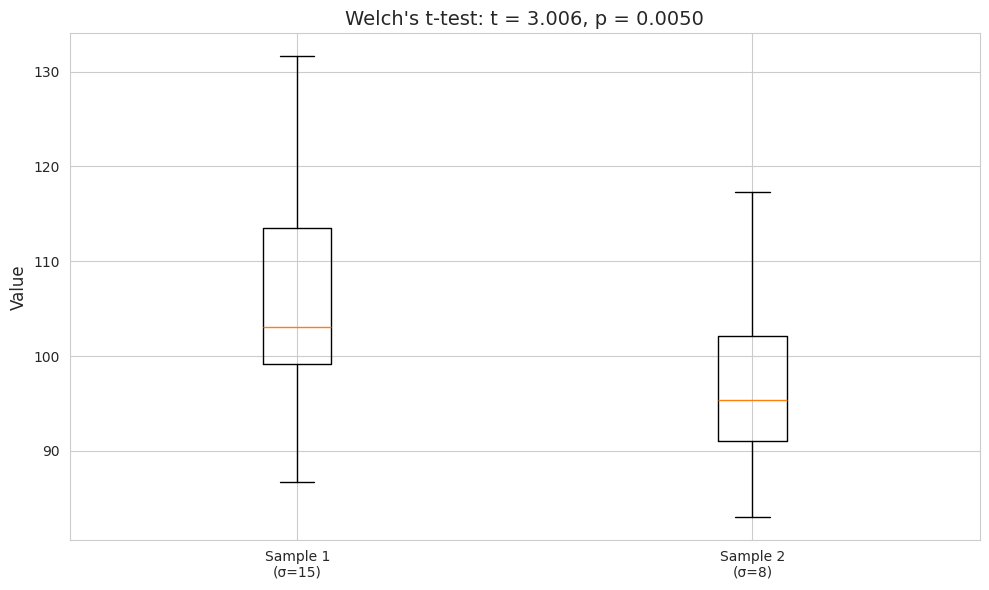

In [7]:
# Welchのt検定（等分散を仮定しない）
np.random.seed(333)

# Two samples with different variances
n1, n2 = 20, 25
sample1 = np.random.normal(105, 15, n1)  # σ1 = 15
sample2 = np.random.normal(100, 8, n2)   # σ2 = 8

mean1, mean2 = np.mean(sample1), np.mean(sample2)
var1, var2 = np.var(sample1, ddof=1), np.var(sample2, ddof=1)

# Welch's t-statistic
t_stat = (mean1 - mean2) / np.sqrt(var1/n1 + var2/n2)

# Welch-Satterthwaite degrees of freedom
nu = (var1/n1 + var2/n2)**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), nu))

print("Welchのt検定 (等分散を仮定しない)")
print("="*50)
print(f"H0: μ1 = μ2")
print(f"\nサンプル1: n1 = {n1}, X̄1 = {mean1:.2f}, S1² = {var1:.2f}")
print(f"サンプル2: n2 = {n2}, X̄2 = {mean2:.2f}, S2² = {var2:.2f}")
print(f"\nt統計量 = {t_stat:.3f}")
print(f"自由度 (Welch-Satterthwaite): {nu:.2f}")
print(f"p値 = {p_value:.4f}")

# Compare with scipy
t_scipy, p_scipy = stats.ttest_ind(sample1, sample2, equal_var=False)
print(f"\nSciPy結果: t = {t_scipy:.3f}, p = {p_scipy:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot([sample1, sample2], labels=['Sample 1\n(σ=15)', 'Sample 2\n(σ=8)'])
ax.set_ylabel('Value', fontsize=12)
ax.set_title(f"Welch's t-test: t = {t_stat:.3f}, p = {p_value:.4f}", fontsize=14)

plt.tight_layout()
plt.show()

## 11.6 対応のあるt検定

### 検定統計量
差 $D_i = X_i - Y_i$ について:
$$T = \frac{\bar{D}}{S_D/\sqrt{n}} \sim t(n-1)$$

対応のあるt検定
H0: μD = 0 (処理効果なし)

サンプルサイズ: n = 15
平均差: D̄ = 5.65
差の標準偏差: SD = 2.10

t統計量 = 10.403
自由度: 14
p値 = 0.0000

SciPy結果: t = 10.403, p = 0.0000


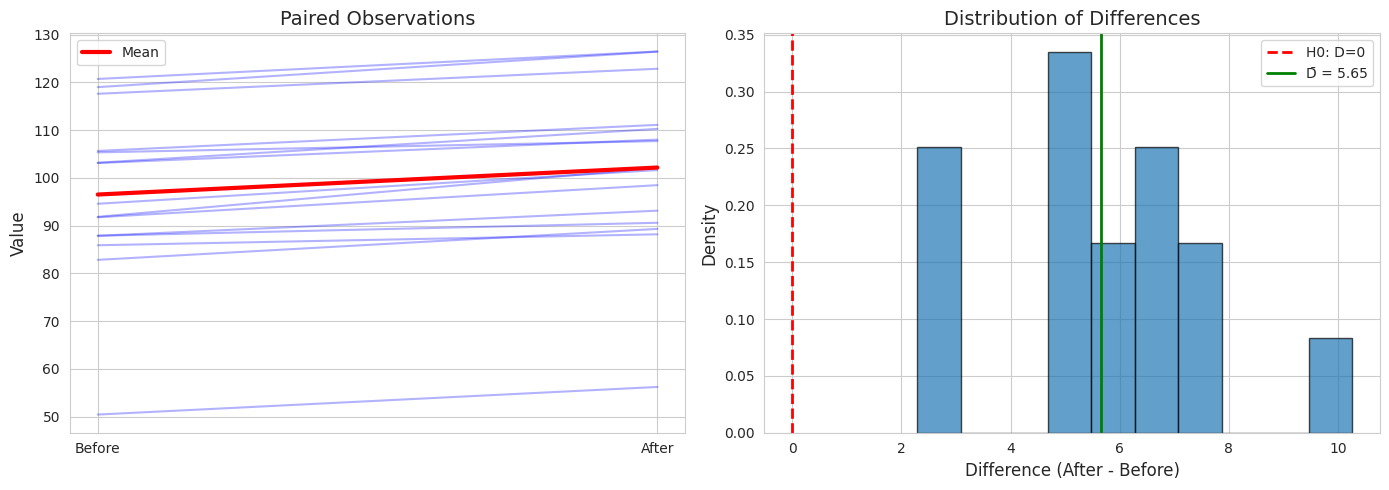

In [8]:
# 対応のあるt検定
np.random.seed(444)

# Paired data (before and after treatment)
n = 15
before = np.random.normal(100, 15, n)
effect = np.random.normal(5, 3, n)  # Treatment effect
after = before + effect

# Differences
diff = after - before
d_bar = np.mean(diff)
s_d = np.std(diff, ddof=1)

# t-test
t_stat = d_bar / (s_d / np.sqrt(n))
df = n - 1
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print("対応のあるt検定")
print("="*50)
print(f"H0: μD = 0 (処理効果なし)")
print(f"\nサンプルサイズ: n = {n}")
print(f"平均差: D̄ = {d_bar:.2f}")
print(f"差の標準偏差: SD = {s_d:.2f}")
print(f"\nt統計量 = {t_stat:.3f}")
print(f"自由度: {df}")
print(f"p値 = {p_value:.4f}")

# Compare with scipy
t_scipy, p_scipy = stats.ttest_rel(after, before)
print(f"\nSciPy結果: t = {t_scipy:.3f}, p = {p_scipy:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before vs After
for i in range(n):
    axes[0].plot([0, 1], [before[i], after[i]], 'b-', alpha=0.3)
axes[0].plot([0, 1], [np.mean(before), np.mean(after)], 'r-', linewidth=3, label='Mean')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Before', 'After'])
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Paired Observations', fontsize=14)
axes[0].legend()

# Histogram of differences
axes[1].hist(diff, bins=10, density=True, alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='H0: D=0')
axes[1].axvline(d_bar, color='green', linewidth=2, label=f'D̄ = {d_bar:.2f}')
axes[1].set_xlabel('Difference (After - Before)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Distribution of Differences', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 11.7 検定の比較と選択

| 状況 | 検定 |
|------|------|
| 一標本、σ既知 | z検定 |
| 一標本、σ未知 | t検定 |
| 二標本、等分散 | 二標本t検定（プール） |
| 二標本、不等分散 | Welchのt検定 |
| 対応あり | 対応のあるt検定 |
| 分散の検定 | カイ二乗検定、F検定 |

In [9]:
# 各検定のType I errorの検証
n_simulations = 10000
alpha = 0.05

# One-sample t-test
n = 20
type1_ttest = 0

for _ in range(n_simulations):
    sample = np.random.normal(0, 1, n)  # H0 is true
    _, p = stats.ttest_1samp(sample, 0)
    if p < alpha:
        type1_ttest += 1

# Two-sample t-test (equal variance)
n1, n2 = 20, 25
type1_ind = 0

for _ in range(n_simulations):
    sample1 = np.random.normal(0, 1, n1)
    sample2 = np.random.normal(0, 1, n2)
    _, p = stats.ttest_ind(sample1, sample2)
    if p < alpha:
        type1_ind += 1

# Welch's t-test
type1_welch = 0

for _ in range(n_simulations):
    sample1 = np.random.normal(0, 1, n1)
    sample2 = np.random.normal(0, 2, n2)  # Different variance
    _, p = stats.ttest_ind(sample1, sample2, equal_var=False)
    if p < alpha:
        type1_welch += 1

print("Type I Error Rate Verification")
print("="*50)
print(f"Nominal α = {alpha}")
print(f"\nOne-sample t-test: {type1_ttest/n_simulations:.4f}")
print(f"Two-sample t-test (equal var): {type1_ind/n_simulations:.4f}")
print(f"Welch's t-test (unequal var): {type1_welch/n_simulations:.4f}")

Type I Error Rate Verification
Nominal α = 0.05

One-sample t-test: 0.0529
Two-sample t-test (equal var): 0.0536
Welch's t-test (unequal var): 0.0467


## 11.8 練習問題

### 問題1
ある製品の重量は $N(\mu, 4)$ に従うとされている。16個のサンプルを取ったところ平均が 102g であった。$H_0: \mu = 100$ vs $H_1: \mu \neq 100$ を有意水準5%で検定せよ。

### 問題2
25人の学生のテスト成績の標本分散が 144 であった。母分散が 100 であるかどうかを有意水準5%で検定せよ。

### 問題3
新薬の効果を調べるため、10人の患者の血圧を投与前後で測定した。前後の差の平均が -5、標準偏差が 6 であった。新薬に効果があるか、有意水準5%で検定せよ。

In [10]:
# 問題1の解答
print("問題1: z検定")
print("="*50)

n = 16
x_bar = 102
mu_0 = 100
sigma2 = 4
sigma = 2
alpha = 0.05

z = (x_bar - mu_0) / (sigma / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z)))
z_crit = stats.norm.ppf(1 - alpha/2)

print(f"\nz = ({x_bar} - {mu_0}) / ({sigma}/√{n})")
print(f"z = {z:.3f}")
print(f"\n臨界値: ±{z_crit:.3f}")
print(f"p値 = {p_value:.4f}")
print(f"\n結論: |z| = {abs(z):.3f} {'>' if abs(z) > z_crit else '<'} {z_crit:.3f}")
print(f"       H0を{'棄却する' if p_value < alpha else '棄却しない'}")

問題1: z検定

z = (102 - 100) / (2/√16)
z = 4.000

臨界値: ±1.960
p値 = 0.0001

結論: |z| = 4.000 > 1.960
       H0を棄却する


In [11]:
# 問題2の解答
print("問題2: 分散のカイ二乗検定")
print("="*50)

n = 25
s2 = 144
sigma2_0 = 100
alpha = 0.05
df = n - 1

chi2 = (n - 1) * s2 / sigma2_0
chi2_lower = stats.chi2.ppf(alpha/2, df)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df)

p_value = 2 * min(stats.chi2.cdf(chi2, df), 1 - stats.chi2.cdf(chi2, df))

print(f"\nχ² = ({n-1} × {s2}) / {sigma2_0}")
print(f"χ² = {chi2:.3f}")
print(f"\n臨界域: χ² < {chi2_lower:.3f} or χ² > {chi2_upper:.3f}")
print(f"p値 = {p_value:.4f}")
print(f"\n結論: H0を{'棄却する' if p_value < alpha else '棄却しない'}")

問題2: 分散のカイ二乗検定

χ² = (24 × 144) / 100
χ² = 34.560

臨界域: χ² < 12.401 or χ² > 39.364
p値 = 0.1504

結論: H0を棄却しない


In [12]:
# 問題3の解答
print("問題3: 対応のあるt検定")
print("="*50)

n = 10
d_bar = -5
s_d = 6
alpha = 0.05
df = n - 1

# One-sided test (H1: mu_D < 0, i.e., blood pressure decreases)
t = d_bar / (s_d / np.sqrt(n))
p_value = stats.t.cdf(t, df)  # Left-tailed

t_crit = -stats.t.ppf(1 - alpha, df)

print(f"\nH0: μD = 0 (効果なし)")
print(f"H1: μD < 0 (血圧低下)")
print(f"\nt = {d_bar} / ({s_d}/√{n})")
print(f"t = {t:.3f}")
print(f"\n臨界値: t < {t_crit:.3f}")
print(f"p値 = {p_value:.4f}")
print(f"\n結論: t = {t:.3f} {'<' if t < t_crit else '>'} {t_crit:.3f}")
print(f"       H0を{'棄却する（新薬に効果あり）' if p_value < alpha else '棄却しない'}")

問題3: 対応のあるt検定

H0: μD = 0 (効果なし)
H1: μD < 0 (血圧低下)

t = -5 / (6/√10)
t = -2.635

臨界値: t < -1.833
p値 = 0.0136

結論: t = -2.635 < -1.833
       H0を棄却する（新薬に効果あり）


## ⚠️ よくある間違いと解決策

### ❌ t検定の前提無視
**正しい理解:** 正規性・等分散性の前提を確認せず使用
**解決策:** Shapiro-Wilk検定やLevene検定で前提を確認

### ❌ 対応あり・なしの混同
**正しい理解:** 対応のあるデータに通常のt検定を使う
**解決策:** paired t-testを使う

---

## 📝 理解度チェッククイズ

### 問題 1
t検定の前提条件は？

### 問題 2
対応のある t検定と対応のない t検定の違いは？

---

## 📚 まとめ

お疲れ様でした！この章の内容は統計的推論の核心部分です。

---